# 14 — ¿La tendencia diaria mejora el pronóstico semanal?

Entradas: base de 10, features diarias del notebook diario 01 y comparación 2026 de 13. Se agregan ventanas de 3 y 5 días (también 7/14), EMA, dispersión, tendencia y cobertura de reportes, todas anteriores al origen. Se compara contra exactamente las predicciones del sistema anterior y del ingeniero, con el mismo reentrenamiento mensual de 13.

Se fijan dos candidatos antes de evaluar: (1) añadir diarios al sistema teórico con respaldo; (2) corrección relativa de media4 usando diarios y teoría completa cuando existe. No se busca una ventana ganadora por prueba y error en 2026. El candidato 1 alimentará el experimento diario, aunque no sea el mejor de este cuadro. Los periodos ya inspeccionados siguen siendo desarrollo retrospectivo, no prueba prospectiva intacta.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


## 1. Unión causal de ventanas diarias

Las features de la fecha del origen usan días estrictamente anteriores. Los faltantes se imputan dentro de cada train y se acompañan de conteos. Se conserva toda la población admisible del experimento anterior.

In [3]:
f=pd.read_parquet(SALIDA/'modelo_diario'/'features_diarias.parquet')
diarias=[c for c in f if c not in KEY+['fecha']]
f=f.rename(columns={'fecha':'origen'})
integrados=integrados.merge(f,on=KEY+['origen'],how='left',validate='many_to_one')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
X_base_diario=X_columnas+diarias
X_teoria_diario=X_teoria+diarias
X_relativo=X_teoria_diario
anterior=pd.read_parquet(DESTINO/'comparacion_ingeniero_modelo_2026.parquet')
llave=KEY+['origen','semana_objetivo','horizonte']
elegibles=datos.merge(anterior[llave],on=llave,how='inner',validate='one_to_one')
assert len(elegibles)==len(anterior)
display(elegibles[diarias].isna().mean().mul(100).to_frame('faltantes_pct'))


,faltantes_pct
corte_media_3d,1.851466
corte_suma_3d,1.851466
corte_dias_3d,0.000000
corte_media_5d,0.714509
corte_suma_5d,0.714509
corte_dias_5d,0.000000
corte_media_7d,0.000000
corte_suma_7d,0.000000
corte_dias_7d,0.000000
corte_media_14d,0.000000


## 2. Entrenamiento mensual sobre los mismos cortes

El ajuste aditivo mantiene los parámetros de 12 y 13. El relativo aprende log(1+real) − log(1+media4); se invierte la transformación y se limita a valores no negativos. Se usa como alternativa para explorar cambios proporcionales, sin prometer que mejore el error en tallos.

In [4]:
resultados=[];control=[]
for mes,test in elegibles.groupby(elegibles.origen.dt.to_period('M'),sort=True):
    corte=test.origen.min()
    train=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    tc=train.loc[train.curva_completa]
    assert train.semana_objetivo.max()+pd.Timedelta(days=7)<=corte
    previo=crear_modelo('Boosting_diario',X_base_diario)
    teorico=crear_modelo('Boosting_teorico_diario',X_teoria_diario)
    relativo=crear_modelo('Boosting_relativo',X_relativo)
    test=test.copy()
    with threadpool_limits(limits=2):
        previo.fit(train[X_base_diario],train.y-train.media_4)
        teorico.fit(tc[X_teoria_diario],tc.y-tc.teoria_modelo)
        relativo.fit(train[X_relativo],np.log1p(train.y)-np.log1p(train.media_4))
        test['Sistema_diario']=np.maximum(0,test.media_4+previo.predict(test[X_base_diario]))
        completa=test.curva_completa
        if completa.any():test.loc[completa,'Sistema_diario']=np.maximum(0,test.loc[completa,'teoria_modelo']+teorico.predict(test.loc[completa,X_teoria_diario]))
        test['Ajuste_relativo_diario']=np.maximum(0,np.expm1(np.log1p(test.media_4)+relativo.predict(test[X_relativo])))
    test['ruta_diaria']=np.where(test.curva_completa,'teoria_con_diarios','media4_con_diarios')
    test['corte_diario']=corte
    resultados.append(test[llave+['Sistema_diario','Ajuste_relativo_diario','ruta_diaria','corte_diario']])
    control.append({'mes':str(mes),'train':len(train),'test':len(test),'train_teoria':len(tc)})
    print(mes,'completo',flush=True)
nuevas=pd.concat(resultados,ignore_index=True)
comparacion=anterior.rename(columns={'modelo':'Sistema_anterior'}).merge(nuevas,on=llave,how='left',validate='one_to_one')
assert len(comparacion)==len(anterior)
assert comparacion[['Sistema_diario','Ajuste_relativo_diario']].notna().all().all()
assert comparacion.corte_diario.eq(comparacion.corte_entrenamiento).all()
display(pd.DataFrame(control))


2026-01 completo


2026-02 completo


2026-03 completo


2026-04 completo


2026-05 completo


2026-06 completo


2026-07 completo


2026-08 completo


,mes,train,test,train_teoria
0,2026-01,123537,2404,39836
1,2026-02,125942,2363,40275
2,2026-03,128320,2927,40552
3,2026-04,131265,2268,40834
4,2026-05,133560,2329,41036
5,2026-06,135874,2828,41163
6,2026-07,138715,2297,41318
7,2026-08,140994,1758,41463


## 3. Resultado, cobertura y variación por horizonte

La comparación principal mantiene entregas nominales y unión estricta del ingeniero. También se comparan los tres sistemas sobre todos los casos disponibles, sin exigir que exista entrega del ingeniero.

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Ajuste_relativo_diario,15838.0,2650.403513,4899.079108,0.206607,1036.635808
Sistema_anterior,15838.0,2614.146745,4740.126294,0.203781,637.313009
Sistema_diario,15838.0,2573.171213,4643.430006,0.200587,501.637581
ingeniero,15838.0,2531.724839,4403.875315,0.197356,1250.135497


n          MAE         RMSE      WAPE  \
horizonte metodo                                                               
1.0       Ajuste_relativo_diario  3413.0  2214.621838  4091.313580  0.175314   
          Sistema_anterior        3413.0  2163.306264  3896.302458  0.171251   
          Sistema_diario          3413.0  2124.646515  3850.755469  0.168191   
          ingeniero               3413.0  2158.891005  3727.656625  0.170902   
2.0       Ajuste_relativo_diario  3289.0  2368.988137  4438.061456  0.185165   
          Sistema_anterior        3289.0  2361.608314  4337.378692  0.184588   
          Sistema_diario          3289.0  2351.038957  4302.120656  0.183762   
          ingeniero               3289.0  2467.040438  4271.206690  0.192829   
3.0       Ajuste_relativo_diario  3166.0  2681.481522  4929.908151  0.209318   
          Sistema_anterior        3166.0  2654.370076  4829.462520  0.207202   
          Sistema_diario          3166.0  2606.663002  4720.419317  0.203478   
          ingeniero               3166.0  2602.472205  4469.143353  0.203151   
4.0       Ajuste_relativo_diario  3045.0  2988.941716  5473.624858  0.230801   
          Sistema_anterior        3045.0  2930.310579  5260.443973  0.226274   
          Sistema_diario          3045.0  2878.754710  5125.886719  0.222293   
          ingeniero               3045.0  2707.974384  4686.461443  0.209105   
5.0       Ajuste_relativo_diario  2925.0  3089.260338  5548.233607  0.237867   
          Sistema_anterior        2925.0  3051.497692  5361.051916  0.234960   
          Sistema_diario          2925.0  2991.930540  5211.919674  0.230373   
          ingeniero               2925.0  2779.438632  4878.863188  0.214012   

                                        sesgo  
horizonte metodo                               
1.0       Ajuste_relativo_diario   903.972993  
          Sistema_anterior         537.335213  
          Sistema_diario           370.591706  
          ingeniero                955.342807  
2.0       Ajuste_relativo_diario  1021.224838  
          Sistema_anterior         668.796137  
          Sistema_diario           523.428178  
          ingeniero               1045.368805  
3.0       Ajuste_relativo_diario  1021.145863  
          Sistema_anterior         606.814298  
          Sistema_diario           489.678980  
          ingeniero               1211.956096  
4.0       Ajuste_relativo_diario  1186.260251  
          Sistema_anterior         737.352623  
          Sistema_diario           606.643375  
          ingeniero               1466.321182  
5.0       Ajuste_relativo_diario  1069.763876  
          Sistema_anterior         647.437627  
          Sistema_diario           533.674702  
          ingeniero               1640.629744

n          MAE         RMSE      WAPE  \
mes     metodo                                                               
2026-01 Ajuste_relativo_diario  1640.0  3234.551360  6066.717233  0.276491   
        Sistema_anterior        1640.0  2858.473723  5215.203126  0.244343   
        Sistema_diario          1640.0  2883.916516  5354.022532  0.246518   
        ingeniero               1640.0  2600.040244  4577.884013  0.222252   
2026-02 Ajuste_relativo_diario  2119.0  2924.027975  5307.976324  0.231610   
        Sistema_anterior        2119.0  2950.935507  5224.623506  0.233741   
        Sistema_diario          2119.0  2867.584899  5148.837852  0.227139   
        ingeniero               2119.0  2717.351581  4570.406771  0.215239   
2026-03 Ajuste_relativo_diario  2568.0  2738.522633  5332.479722  0.183048   
        Sistema_anterior        2568.0  2779.736377  5435.686867  0.185802   
        Sistema_diario          2568.0  2755.579335  5288.409261  0.184188   
        ingeniero               2568.0  2866.958723  5354.799141  0.191633   
2026-04 Ajuste_relativo_diario  1486.0  2834.775863  4528.722260  0.203632   
        Sistema_anterior        1486.0  2785.670034  4362.866554  0.200104   
        Sistema_diario          1486.0  2713.759573  4186.131487  0.194939   
        ingeniero               1486.0  2704.843203  4656.771018  0.194298   
2026-05 Ajuste_relativo_diario  1989.0  2520.488755  4146.023450  0.193557   
        Sistema_anterior        1989.0  2579.953135  4294.095588  0.198123   
        Sistema_diario          1989.0  2515.503189  4230.832548  0.193174   
        ingeniero               1989.0  3329.294620  5370.479461  0.255668   
2026-06 Ajuste_relativo_diario  2461.0  2442.625552  4463.169779  0.202917   
        Sistema_anterior        2461.0  2498.142744  4381.008044  0.207529   
        Sistema_diario          2461.0  2475.914552  4204.733854  0.205682   
        ingeniero               2461.0  2346.831369  3871.300045  0.194959   
2026-07 Ajuste_relativo_diario  2015.0  2610.915144  5201.131516  0.218407   
        Sistema_anterior        2015.0  2446.911310  4876.509245  0.204688   
        Sistema_diario          2015.0  2403.236174  4725.201623  0.201034   
        ingeniero               2015.0  1756.685856  2803.652754  0.146949   
2026-08 Ajuste_relativo_diario  1560.0  1888.372202  3475.579927  0.159093   
        Sistema_anterior        1560.0  1906.458875  3342.126094  0.160617   
        Sistema_diario          1560.0  1858.841842  3236.382256  0.156606   
        ingeniero               1560.0  1766.882051  2840.160103  0.148858   

                                      sesgo  
mes     metodo                               
2026-01 Ajuste_relativo_diario  1929.514662  
        Sistema_anterior         833.868455  
        Sistema_diario          1094.460136  
        ingeniero               1135.296341  
2026-02 Ajuste_relativo_diario  1394.520882  
        Sistema_anterior        1040.306287  
        Sistema_diario           832.465868  
        ingeniero               1997.038226  
2026-03 Ajuste_relativo_diario   537.519961  
        Sistema_anterior         620.423141  
        Sistema_diario           291.356647  
        ingeniero               1109.007788  
2026-04 Ajuste_relativo_diario  -737.091664  
        Sistema_anterior       -1011.061053  
        Sistema_diario          -949.439113  
        ingeniero               1154.281965  
2026-05 Ajuste_relativo_diario  1652.224400  
        Sistema_anterior        1546.179616  
        Sistema_diario          1433.847548  
        ingeniero               2751.099548  
2026-06 Ajuste_relativo_diario  1054.130908  
        Sistema_anterior         405.096011  
        Sistema_diario           209.872805  
        ingeniero               1116.806989  
2026-07 Ajuste_relativo_diario  1677.866430  
        Sistema_anterior        1020.114580  
        Sistema_diario           818.972500  
        ingeniero                254.083375  
2026

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Ajuste_relativo_diario,19174.0,2435.823057,4671.732419,0.211239,947.197809
Sistema_anterior,19174.0,2397.306452,4497.674088,0.207898,540.431717
Sistema_diario,19174.0,2359.548023,4408.905522,0.204624,457.602604


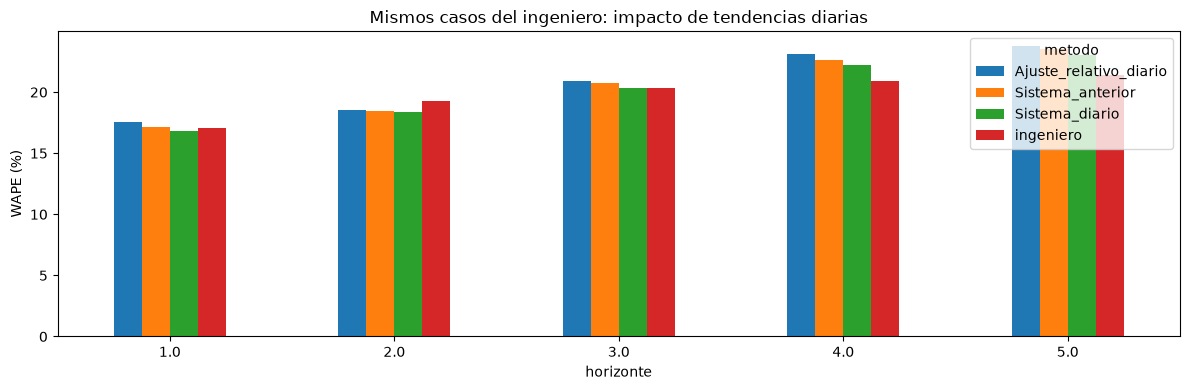

Cambio WAPE a favor de añadir diarios: 0.31941740284039677
Diferencia a favor del sistema diario frente al ingeniero: -0.32308776315095045
No elegir un ganador operativo con el mismo conjunto ya inspeccionado.


In [5]:
def evaluar(g):
    error=g.y-g.prediccion
    return pd.Series({'n':len(g),'MAE':error.abs().mean(),'RMSE':np.sqrt((error**2).mean()),'WAPE':error.abs().sum()/g.y.sum(),'sesgo':error.mean()})
modelos=['Sistema_anterior','Sistema_diario','Ajuste_relativo_diario']
principal=comparacion.loc[comparacion.grupo_comparacion.eq('principal_estricta_nominal')]
larga=principal.melt(id_vars=llave+['y'],value_vars=['ingeniero']+modelos,var_name='metodo',value_name='prediccion')
assert larga.groupby(llave).metodo.nunique().eq(4).all()
resumen=larga.groupby('metodo').apply(evaluar)
por_h=larga.groupby(['horizonte','metodo']).apply(evaluar)
por_mes=larga.groupby([larga.origen.dt.to_period('M').astype(str).rename('mes'),'metodo']).apply(evaluar)
display(resumen);display(por_h);display(por_mes)
todos=comparacion.melt(id_vars=llave+['y'],value_vars=modelos,var_name='metodo',value_name='prediccion')
display(todos.groupby('metodo').apply(evaluar))
por_h.WAPE.unstack().mul(100).plot.bar(figsize=(12,4),ylabel='WAPE (%)',rot=0,title='Mismos casos del ingeniero: impacto de tendencias diarias');plt.tight_layout();plt.show()
print('Cambio WAPE a favor de añadir diarios:',100*(resumen.loc['Sistema_anterior','WAPE']-resumen.loc['Sistema_diario','WAPE']))
print('Diferencia a favor del sistema diario frente al ingeniero:',100*(resumen.loc['ingeniero','WAPE']-resumen.loc['Sistema_diario','WAPE']))
print('No elegir un ganador operativo con el mismo conjunto ya inspeccionado.')
comparacion.to_parquet(DESTINO/'comparacion_features_diarias_2026.parquet',index=False)
with pd.ExcelWriter(DESTINO/'resultados_features_diarias_2026.xlsx') as w:
    resumen.to_excel(w,sheet_name='Resumen');por_h.to_excel(w,sheet_name='Horizonte');por_mes.to_excel(w,sheet_name='Mes')
    comparacion.to_excel(w,sheet_name='Casos',index=False)


## 4. Incertidumbre emparejada y diferencias entre variedades

Las semanas objetivo son bloques de remuestreo: se mantienen juntos sus orígenes y horizontes. El desglose por producto y serie evita interpretar una mejora agregada como mejora universal. La comparación sigue siendo retrospectiva.

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').is_dir())
DESTINO=ROOT/'Datos_analiticos_proyecto'/'modelo_con_proyecciones_teoricas'
d=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet')
d=d.loc[d.grupo_comparacion.eq('principal_estricta_nominal')].copy()
rng=np.random.default_rng(42);filas=[]
for candidato,referencia in [('Sistema_diario','ingeniero'),('Ajuste_relativo_diario','ingeniero'),('Sistema_diario','Sistema_anterior')]:
    z=d.assign(error_referencia=(d.y-d[referencia]).abs(),error_candidato=(d.y-d[candidato]).abs())
    bloque=z.groupby('semana_objetivo')[['error_referencia','error_candidato','y']].sum().to_numpy(dtype=float)
    indices=rng.integers(0,len(bloque),size=(1000,len(bloque)))
    muestras=bloque[indices].sum(axis=1)
    delta=100*(muestras[:,0]-muestras[:,1])/muestras[:,2]
    estimacion=100*(bloque[:,0].sum()-bloque[:,1].sum())/bloque[:,2].sum()
    filas.append({'candidato':candidato,'referencia':referencia,'mejora_puntos_WAPE':estimacion,'limite_2_5':np.quantile(delta,.025),'limite_97_5':np.quantile(delta,.975)})
incertidumbre=pd.DataFrame(filas)
display(incertidumbre)
print('Positivo favorece al candidato. Un intervalo que cruza cero no aporta evidencia clara de superioridad. Remuestreo exploratorio: no elimina toda dependencia temporal.')
long=d.melt(id_vars=['producto','color','variedad','y'],value_vars=['ingeniero','Sistema_anterior','Sistema_diario','Ajuste_relativo_diario'],var_name='metodo',value_name='prediccion')
def resumen_segmento(g):
    return pd.Series({'n':len(g),'WAPE':(g.y-g.prediccion).abs().sum()/g.y.sum() if g.y.sum()>0 else np.nan,'sesgo':(g.y-g.prediccion).mean()})
producto=long.groupby(['producto','metodo']).apply(resumen_segmento)
variedad=long.groupby(['producto','color','variedad','metodo']).apply(resumen_segmento)
display(producto)
display(variedad.groupby('metodo').agg(series=('n','size'),mediana_WAPE=('WAPE','median')))
with pd.ExcelWriter(DESTINO/'resultados_features_diarias_2026.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as writer:
    incertidumbre.to_excel(writer,sheet_name='Incertidumbre',index=False)
    producto.to_excel(writer,sheet_name='Producto')
    variedad.to_excel(writer,sheet_name='Variedad')


,candidato,referencia,mejora_puntos_WAPE,limite_2_5,limite_97_5
0,Sistema_diario,ingeniero,-0.323088,-1.739819,1.126610
1,Ajuste_relativo_diario,ingeniero,-0.925138,-2.659833,0.621934
2,Sistema_diario,Sistema_anterior,0.319417,0.137359,0.488636


Positivo favorece al candidato. Un intervalo que cruza cero no aporta evidencia clara de superioridad. Remuestreo exploratorio: no elimina toda dependencia temporal.


n      WAPE        sesgo
producto       metodo                                               
ACHILLEA       Ajuste_relativo_diario   155.0  0.542620    -7.331097
               Sistema_anterior         155.0  7.449571  -247.720365
               Sistema_diario           155.0  7.888623  -255.717241
               ingeniero                155.0  0.998118    33.374194
AMAZON         Ajuste_relativo_diario   155.0  0.289758  -106.679146
               Sistema_anterior         155.0  0.325562  -250.235830
               Sistema_diario           155.0  0.337967  -280.769102
               ingeniero                155.0  0.221614    -9.322581
BARBATUS       Ajuste_relativo_diario   775.0  0.298700    77.371942
               Sistema_anterior         775.0  0.342900  -144.471055
               Sistema_diario           775.0  0.332053   -99.347779
               ingeniero                775.0  0.285350    37.077419
CARNATION      Ajuste_relativo_diario  5825.0  0.242146   551.871059
               Sistema_anterior        5825.0  0.239064   151.620013
               Sistema_diario          5825.0  0.240132   111.659076
               ingeniero               5825.0  0.224297   565.728755
GREEN BALL     Ajuste_relativo_diario   155.0  0.196791  -137.293171
               Sistema_anterior         155.0  0.194105  -709.064648
               Sistema_diario           155.0  0.190092  -647.641742
               ingeniero                155.0  0.185370  -237.225806
MINICARNATION  Ajuste_relativo_diario  4567.0  0.193692  2663.571114
               Sistema_anterior        4567.0  0.189290  2047.278634
               Sistema_diario          4567.0  0.183401  1695.522888
               ingeniero               4567.0  0.177519  2470.211955
RAFFINE        Ajuste_relativo_diario   945.0  0.226745   626.348982
               Sistema_anterior         945.0  0.232486   227.348014
               Sistema_diario           945.0  0.230881   105.479283
               ingeniero                945.0  0.293590  1783.705820
SOLOMIO        Ajuste_relativo_diario  1860.0  0.190317   193.570063
               Sistema_anterior        1860.0  0.185066    21.169421
               Sistema_diario          1860.0  0.187256  -110.696779
               ingeniero               1860.0  0.185386  1472.979570
STAR           Ajuste_relativo_diario   158.0  0.191939   300.937619
               Sistema_anterior         158.0  0.185983    42.443044
               Sistema_diario           158.0  0.193285    13.362228
               ingeniero                158.0  0.207502  2423.569620
STATICE        Ajuste_relativo_diario   475.0  0.336855   -35.261676
               Sistema_anterior         475.0  0.337651   -58.929108
               Sistema_diario           475.0  0.350402   -38.506312
               ingeniero                475.0  0.360692    54.242105
TRACHELIUM     Ajuste_relativo_diario   148.0  0.442092   261.810448
               Sistema_anterior         148.0  0.432911   193.329006
               Sistema_diario           148.0  0.423737   192.208521
               ingeniero                148.0  0.473568  1298.445946
VERONICA       Ajuste_relativo_diario   310.0  0.257994   -17.382067
               Sistema_anterior         310.0  0.280191  -134.716612
               Sistema_diario           310.0  0.287495  -125.818854
               ingeniero                310.0  0.343886   475.951613
VERONICA SPRAY Ajuste_relativo_diario   310.0  0.267176     6.290460
               Sistema_anterior         310.0  0.308775  -193.792181
               Sistema_diario           310.0  0.306381  -178.846542
               ingeniero                310.0  0.261648   172.183871

,series,mediana_WAPE
metodo,,
Ajuste_relativo_diario,123,0.226721
Sistema_anterior,123,0.224348
Sistema_diario,123,0.224464
ingeniero,123,0.221047


## 5. Variante exploratoria: pérdida de error absoluto

Se alinea la función de entrenamiento con MAE/WAPE y se usa una corrección conjunta de media4, con teoría disponible como predictor. Esto cambia tanto la pérdida como la forma de combinar teoría/respaldo; no atribuir todo el cambio únicamente a la pérdida. Se propone después de inspeccionar los primeros resultados, por lo que requiere validación nueva. El reparto diario mantiene el candidato aditivo fijado en la sección 2.

In [7]:
# Variante exploratoria adicional: pérdida MAE sobre corrección de media4.
# Sobre una población fija, minimizar MAE y WAPE tiene el mismo numerador.
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').is_dir())
DESTINO=ROOT/'Datos_analiticos_proyecto'/'modelo_con_proyecciones_teoricas'
KEY=['finca','producto','color','variedad'];llave=KEY+['origen','semana_objetivo','horizonte']
base=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
f=pd.read_parquet(ROOT/'Datos_analiticos_proyecto/modelo_diario/features_diarias.parquet').rename(columns={'fecha':'origen'})
diarias=[c for c in f if c not in KEY+['origen']]
base=base.merge(f,on=KEY+['origen'],how='left',validate='many_to_one')
base=base.loc[base.admisible_modelo&base.y.notna()]
cats=['producto','color','variedad']
num=['horizonte','semana_seno','semana_coseno','produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52','teoria_modelo','antiguedad_curva','desviacion_reciente_teoria','curva_completa']+[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]+diarias
comparacion=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet').drop(columns='Boosting_diario_MAE',errors='ignore')
elegibles=base.merge(comparacion[llave],on=llave,how='inner',validate='one_to_one')
salidas=[]
for mes,test in elegibles.groupby(elegibles.origen.dt.to_period('M')):
    corte=test.origen.min();train=base.loc[(base.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    pre=ColumnTransformer([('cats',OneHotEncoder(handle_unknown='ignore',sparse_output=False,dtype=np.float32),cats),('num',SimpleImputer(strategy='median',add_indicator=True,keep_empty_features=True),num)])
    m=make_pipeline(pre,HistGradientBoostingRegressor(loss='absolute_error',learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,l2_regularization=1,early_stopping=False,random_state=42))
    with threadpool_limits(limits=2):
        m.fit(train[cats+num],train.y-train.media_4)
        estimado=np.maximum(0,test.media_4+m.predict(test[cats+num]))
    z=test[llave].copy();z['Boosting_diario_MAE']=np.asarray(estimado);salidas.append(z)
comparacion=comparacion.merge(pd.concat(salidas,ignore_index=True),on=llave,validate='one_to_one')
assert comparacion.Boosting_diario_MAE.notna().all()
principal=comparacion.loc[comparacion.grupo_comparacion.eq('principal_estricta_nominal')]
metodos=['ingeniero','Sistema_anterior','Sistema_diario','Ajuste_relativo_diario','Boosting_diario_MAE']
larga=principal.melt(id_vars=llave+['y'],value_vars=metodos,var_name='metodo',value_name='prediccion')
def evaluar(g):
    e=g.y-g.prediccion
    return pd.Series({'n':len(g),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'WAPE':e.abs().sum()/g.y.sum(),'sesgo':e.mean()})
resumen=larga.groupby('metodo').apply(evaluar)
por_h=larga.groupby(['horizonte','metodo']).apply(evaluar)
por_mes=larga.groupby([larga.origen.dt.to_period('M').astype(str).rename('mes'),'metodo']).apply(evaluar)
display(resumen);display(por_h)
z=principal.assign(diferencia=(principal.y-principal.ingeniero).abs()-(principal.y-principal.Boosting_diario_MAE).abs())
bloque=z.groupby('semana_objetivo')[['diferencia','y']].sum().to_numpy(dtype=float)
rng=np.random.default_rng(42);indices=rng.integers(0,len(bloque),size=(1000,len(bloque)))
muestras=bloque[indices].sum(axis=1);intervalo=np.quantile(100*muestras[:,0]/muestras[:,1],[.025,.975])
print('MAE vs ingeniero: diferencia favorable en puntos WAPE:',100*bloque[:,0].sum()/bloque[:,1].sum(),'; intervalo exploratorio:',intervalo)
print('Variante exploratoria después de inspeccionar resultados. No constituye selección prospectiva ni modifica el candidato diario fijado previamente.')
comparacion.to_parquet(DESTINO/'comparacion_features_diarias_2026.parquet',index=False)
with pd.ExcelWriter(DESTINO/'resultados_features_diarias_2026.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as writer:
    resumen.to_excel(writer,sheet_name='Resumen');por_h.to_excel(writer,sheet_name='Horizonte');por_mes.to_excel(writer,sheet_name='Mes');comparacion.to_excel(writer,sheet_name='Casos',index=False)
    larga.groupby(['producto','metodo']).apply(evaluar).to_excel(writer,sheet_name='Producto')
    larga.groupby(['producto','color','variedad','metodo']).apply(evaluar).to_excel(writer,sheet_name='Variedad')


,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Ajuste_relativo_diario,15838.0,2650.403513,4899.079108,0.206607,1036.635808
Boosting_diario_MAE,15838.0,2569.943983,4789.325470,0.200335,936.780223
Sistema_anterior,15838.0,2614.146745,4740.126294,0.203781,637.313009
Sistema_diario,15838.0,2573.171213,4643.430006,0.200587,501.637581
ingeniero,15838.0,2531.724839,4403.875315,0.197356,1250.135497


n          MAE         RMSE      WAPE  \
horizonte metodo                                                               
1.0       Ajuste_relativo_diario  3413.0  2214.621838  4091.313580  0.175314   
          Boosting_diario_MAE     3413.0  2034.169526  3862.659328  0.161029   
          Sistema_anterior        3413.0  2163.306264  3896.302458  0.171251   
          Sistema_diario          3413.0  2124.646515  3850.755469  0.168191   
          ingeniero               3413.0  2158.891005  3727.656625  0.170902   
2.0       Ajuste_relativo_diario  3289.0  2368.988137  4438.061456  0.185165   
          Boosting_diario_MAE     3289.0  2294.553412  4344.903445  0.179347   
          Sistema_anterior        3289.0  2361.608314  4337.378692  0.184588   
          Sistema_diario          3289.0  2351.038957  4302.120656  0.183762   
          ingeniero               3289.0  2467.040438  4271.206690  0.192829   
3.0       Ajuste_relativo_diario  3166.0  2681.481522  4929.908151  0.209318   
          Boosting_diario_MAE     3166.0  2620.720760  4842.535587  0.204575   
          Sistema_anterior        3166.0  2654.370076  4829.462520  0.207202   
          Sistema_diario          3166.0  2606.663002  4720.419317  0.203478   
          ingeniero               3166.0  2602.472205  4469.143353  0.203151   
4.0       Ajuste_relativo_diario  3045.0  2988.941716  5473.624858  0.230801   
          Boosting_diario_MAE     3045.0  2938.069429  5369.041620  0.226873   
          Sistema_anterior        3045.0  2930.310579  5260.443973  0.226274   
          Sistema_diario          3045.0  2878.754710  5125.886719  0.222293   
          ingeniero               3045.0  2707.974384  4686.461443  0.209105   
5.0       Ajuste_relativo_diario  2925.0  3089.260338  5548.233607  0.237867   
          Boosting_diario_MAE     2925.0  3066.578703  5492.911907  0.236121   
          Sistema_anterior        2925.0  3051.497692  5361.051916  0.234960   
          Sistema_diario          2925.0  2991.930540  5211.919674  0.230373   
          ingeniero               2925.0  2779.438632  4878.863188  0.214012   

                                        sesgo  
horizonte metodo                               
1.0       Ajuste_relativo_diario   903.972993  
          Boosting_diario_MAE      801.152484  
          Sistema_anterior         537.335213  
          Sistema_diario           370.591706  
          ingeniero                955.342807  
2.0       Ajuste_relativo_diario  1021.224838  
          Boosting_diario_MAE      921.761314  
          Sistema_anterior         668.796137  
          Sistema_diario           523.428178  
          ingeniero               1045.368805  
3.0       Ajuste_relativo_diario  1021.145863  
          Boosting_diario_MAE      965.113748  
          Sistema_anterior         606.814298  
          Sistema_diario           489.678980  
          ingeniero               1211.956096  
4.0       Ajuste_relativo_diario  1186.260251  
          Boosting_diario_MAE     1071.579920  
          Sistema_anterior         737.352623  
          Sistema_diario           606.643375  
          ingeniero               1466.321182  
5.0       Ajuste_relativo_diario  1069.763876  
          Boosting_diario_MAE      940.925741  
          Sistema_anterior         647.437627  
          Sistema_diario           533.674702  
          ingeniero               1640.629744

MAE vs ingeniero: diferencia favorable en puntos WAPE: -0.29793047634135716 ; intervalo exploratorio: [-1.86002776  1.36181615]
Variante exploratoria después de inspeccionar resultados. No constituye selección prospectiva ni modifica el candidato diario fijado previamente.


## 6. Comparación verificada con el ingeniero en H1–H5

Esta sección puede ejecutarse sola con las salidas existentes. Reconstruye los estimados del ingeniero desde la fuente limpia y verifica origen, objetivo, horizonte, archivo y cantidad para todos los casos principales. H1 es la semana del origen; H2, la siguiente; H5, cuatro semanas después. Cada estimado se contrasta con la producción real de su semana objetivo.

La comparación principal usa todos los casos emparejados disponibles. Se añade una sensibilidad que exige los cinco horizontes para cada serie y origen. Esta segunda población facilita comparar horizontes, pero es más restringida. Se mantiene el sistema aditivo con tendencias diarias ya evaluado, sin reentrenar ni seleccionar un nuevo candidato. Menor WAPE es mejor; ventaja positiva favorece al modelo.


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').exists())
DATA=ROOT/'Datos_analiticos_proyecto'
OUT=DATA/'modelo_con_proyecciones_teoricas'
keys=['finca','producto','color','variedad','origen','semana_objetivo','horizonte']
c=pd.read_parquet(OUT/'comparacion_features_diarias_2026.parquet')
c=c.loc[c.grupo_comparacion.eq('principal_estricta_nominal')].copy()
e=pd.read_parquet(DATA/'estimados_semanales_limpio.parquet')
e=e.loc[e.finca.eq('GAITANA')&e.en_h1_h5&~e.es_ajustado&e.origen_solicitado.dt.year.eq(2026)&~e.archivo_es_posterior].copy()
e=e.rename(columns={'origen_solicitado':'origen','semana_inicio':'semana_objetivo'})
assert e.horizonte.eq(e.horizonte_nominal).all()
assert e.origen.eq(e.origen_nominal).all()
assert ((e.semana_objetivo-e.origen).dt.days==7*(e.horizonte-1)).all()
g=e.groupby(keys,dropna=False)
source=g.agg(estimado_fuente=('estimado',lambda x:x.sum(min_count=1)),archivo_fuente=('archivo_origen','first'),archivos=('archivo_origen','nunique')).reset_index()
assert source.archivos.eq(1).all()
audit=c.merge(source,on=keys,how='left',validate='one_to_one')
assert len(audit)==15838 and audit.estimado_fuente.notna().all()
assert np.allclose(audit.ingeniero,audit.estimado_fuente)
assert audit.archivo.eq(audit.archivo_fuente).all()

def resumen(g):
    ei=(g.y-g.ingeniero).abs()
    em=(g.y-g.Sistema_diario).abs()
    wi=100*ei.sum()/g.y.sum(); wm=100*em.sum()/g.y.sum()
    return pd.Series({'casos':len(g),'origenes':g.origen.nunique(),'WAPE_ingeniero_pct':wi,'WAPE_modelo_pct':wm,'ventaja_modelo_pp':wi-wm,'MAE_ingeniero':ei.mean(),'MAE_modelo':em.mean(),'ganador':'Modelo' if wm<wi else 'Ingeniero'})

tabla=audit.groupby('horizonte').apply(resumen)
tabla.index=[f'H{int(h)}' for h in tabla.index]
tabla.loc['H1–H5 conjunto']=resumen(audit)
print('Comparación principal: mismos casos para ambos métodos dentro de cada horizonte.')
display(tabla)
print('El WAPE conjunto suma errores absolutos y producción real; no promedia porcentajes ni suma errores con signo.')

# Sensibilidad: mismas series y orígenes con los cinco horizontes observados.
panelkeys=['finca','producto','color','variedad','origen']
assert not audit.duplicated(keys).any()
balanced=audit.loc[audit.groupby(panelkeys).horizonte.transform('nunique').eq(5)].copy()
assert balanced.groupby(panelkeys).size().eq(5).all()
sens=balanced.groupby('horizonte').apply(resumen)
sens.index=[f'H{int(h)}' for h in sens.index]
sens.loc['H1–H5 conjunto']=resumen(balanced)
print('Sensibilidad: panel con los cinco horizontes por cada serie y origen; población más restringida.')
display(sens)
control=audit.groupby('horizonte').agg(casos=('y','size'),archivos=('archivo','nunique'),origen_min=('origen','min'),origen_max=('origen','max'),objetivo_max=('semana_objetivo','max'))
display(control)
ejemplo=audit.sort_values(keys).groupby('horizonte',as_index=False).head(1)[keys+['archivo','ingeniero','estimado_fuente','Sistema_diario','y']]
display(ejemplo)
with pd.ExcelWriter(OUT/'comparacion_H1_H5_verificada.xlsx') as writer:
    tabla.to_excel(writer,sheet_name='Comparacion_principal')
    sens.to_excel(writer,sheet_name='Panel_cinco_horizontes')
    control.to_excel(writer,sheet_name='Cobertura')
    ejemplo.to_excel(writer,sheet_name='Ejemplos_trazabilidad',index=False)
print('H2–H5 son valores propios del ingeniero para las semanas objetivo, no H1 repetido ni producción real futura.')
print('Disponibilidad nominal, no publicación histórica certificada. Evaluación retrospectiva de tallos reportados; equivalencia exportable pendiente.')
print('Conclusión principal:',tabla.loc['H1–H5 conjunto','ganador'],'tiene menor WAPE conjunto.')


Comparación principal: mismos casos para ambos métodos dentro de cada horizonte.


,casos,origenes,WAPE_ingeniero_pct,WAPE_modelo_pct,ventaja_modelo_pp,MAE_ingeniero,MAE_modelo,ganador
H1,3413,33,17.090192,16.819106,0.271086,2158.891005,2124.646515,Modelo
H2,3289,32,19.282910,18.376218,0.906692,2467.040438,2351.038957,Modelo
H3,3166,31,20.315054,20.347768,-0.032714,2602.472205,2606.663002,Ingeniero
H4,3045,30,20.910523,22.229260,-1.318737,2707.974384,2878.754710,Ingeniero
H5,2925,29,21.401171,23.037320,-1.636149,2779.438632,2991.930540,Ingeniero
H1–H5 conjunto,15838,33,19.735606,20.058694,-0.323088,2531.724839,2573.171213,Ingeniero


El WAPE conjunto suma errores absolutos y producción real; no promedia porcentajes ni suma errores con signo.
Sensibilidad: panel con los cinco horizontes por cada serie y origen; población más restringida.


,casos,origenes,WAPE_ingeniero_pct,WAPE_modelo_pct,ventaja_modelo_pp,MAE_ingeniero,MAE_modelo,ganador
H1,2917,29,17.312295,17.065489,0.246806,2255.760370,2223.602020,Modelo
H2,2917,29,19.731024,18.631083,1.099940,2595.850531,2451.140330,Modelo
H3,2917,29,20.624394,20.577742,0.046652,2689.147069,2683.064324,Modelo
H4,2917,29,21.050795,22.376439,-1.325644,2752.762427,2926.113703,Ingeniero
H5,2917,29,21.398775,23.028872,-1.630097,2786.687693,2998.969587,Ingeniero
H1–H5 conjunto,14585,29,20.023560,20.333831,-0.310271,2616.041618,2656.577993,Ingeniero


,casos,archivos,origen_min,origen_max,objetivo_max
horizonte,,,,,
1.0,3413,33,2026-01-12,2026-08-31,2026-08-31
2.0,3289,32,2026-01-12,2026-08-24,2026-08-31
3.0,3166,31,2026-01-12,2026-08-17,2026-08-31
4.0,3045,30,2026-01-12,2026-08-10,2026-08-31
5.0,2925,29,2026-01-12,2026-08-03,2026-08-31


,finca,producto,color,variedad,origen,semana_objetivo,horizonte,archivo,ingeniero,estimado_fuente,Sistema_diario,y
0,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2026-01-12,2026-01-12,1.0,Datos/Estimados semanales/2026/Estimado Sem 03...,30.0,30.0,98.823580,50
335,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2026-01-12,2026-01-19,2.0,Datos/Estimados semanales/2026/Estimado Sem 03...,0.0,0.0,98.823580,100
667,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2026-01-12,2026-01-26,3.0,Datos/Estimados semanales/2026/Estimado Sem 03...,0.0,0.0,160.289516,72
994,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2026-01-12,2026-02-02,4.0,Datos/Estimados semanales/2026/Estimado Sem 03...,0.0,0.0,160.289516,18
1318,GAITANA,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2026-01-12,2026-02-09,5.0,Datos/Estimados semanales/2026/Estimado Sem 03...,0.0,0.0,160.289516,30


H2–H5 son valores propios del ingeniero para las semanas objetivo, no H1 repetido ni producción real futura.
Disponibilidad nominal, no publicación histórica certificada. Evaluación retrospectiva de tallos reportados; equivalencia exportable pendiente.
Conclusión principal: Ingeniero tiene menor WAPE conjunto.
